1.Информация о датасете.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

Кол-во пропусков в признаках:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca       

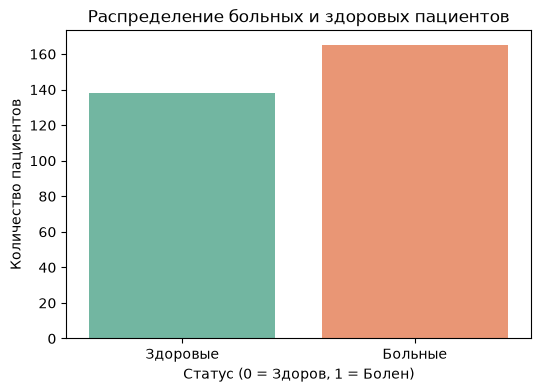

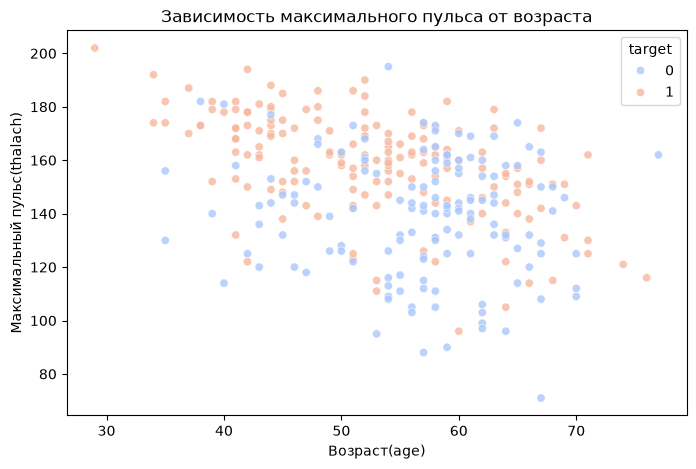


--Результат One-Hot Encoding(первые 5 строк)--
   sex_female  sex_male
0       False      True
1       False      True
2        True     False
3       False      True
4        True     False

--Средний уровень холестерина(chol)--
Здоровые пациенты(target 0): 251.09
Больные пациенты(target 1): 242.23

--Результат нормализации(первые 5 строк)--
        age  trestbps      chol   thalach
0  0.708333  0.481132  0.244292  0.603053
1  0.166667  0.339623  0.283105  0.885496
2  0.250000  0.339623  0.178082  0.770992
3  0.562500  0.245283  0.251142  0.816794
4  0.583333  0.245283  0.520548  0.702290


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

#загружаем файл ксв
file_path='/home/s/DataScince/Sosinovich_DS_2026/Sosinovich_hw_2/heart.csv'
df = pd.read_csv(file_path)

print("1.Информация о датасете.")
df.info()
print("\nКол-во пропусков в признаках:")
print (df.isnull().sum())

#создаём диаграмму:здоровых и больных
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', hue='target', palette='Set2', legend=False)
plt.title('Распределение больных и здоровых пациентов')
plt.xlabel('Статус (0 = Здоров, 1 = Болен)')
plt.ylabel('Количество пациентов')
plt.xticks([0,1], ['Здоровые', 'Больные'])
plt.show()

#строим диаграмму рассеяния: thalach от age с расцветкой по таргет
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x= 'age', y= 'thalach', hue= 'target', palette='coolwarm', alpha=0.8)
plt.title('Зависимость максимального пульса от возраста')
plt.xlabel('Возраст(age)')
plt.ylabel('Максимальный пульс(thalach)')
plt.show()

#преобразовываем признаки sex и One-Hot Encoding
df['sex'] = df['sex'].map({0:'female', 1:'male'})
df= pd.get_dummies(df, columns=['sex'], drop_first=False)
print("\n--Результат One-Hot Encoding(первые 5 строк)--")
print(df[['sex_female', 'sex_male']].head())

#средний уровень холестерина(chol) для больных и здоровых
mean_chol = df.groupby('target')['chol'].mean()
print("\n--Средний уровень холестерина(chol)--")
print(f"Здоровые пациенты(target 0): {mean_chol[0]:.2f}")
print(f"Больные пациенты(target 1): {mean_chol[1]:.2f}")

#нормализация признаков age, trestbps, chol, thalach
scaler = MinMaxScaler()
features_to_scale = ['age', 'trestbps', 'chol', 'thalach']
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("\n--Результат нормализации(первые 5 строк)--")
print(df[features_to_scale].head())

In [ ]:
отчёт по домашнему заданию 2 Сосиновича Е.И,

--данные успешно загружены из файла 'heart.csv'. В ходе проверки методом 'df.isnull().sum()' пропусков не обнаружено(все значения "0").
--визуализация данных:
-была построена столбчатая диаграмма распределения целевой переменной "target"
-была построена диаграмма рассеяния:график зависимости макс пульса ('thalach') от возраста('age'),на диаграмме наблюдается выраженная отрицательная линейная зависимость - с увеличением возраста макс пульсснижается, при этом больные пациенты чаще имеют более высокий пульс для своеговозрастапо сравнению со здоровыми людьми.
--категориальный признак успешно закодирован и преобразован.
--показатели среднего уровня холестерина у здоровых пациентов-251.09 мг/дл,а у больных-242.23 мг/дл,разбежка не большая,поэтому уровень холестерина в этой выборке не являетсяопределяющим фактором болезни.
--признаки 'age', 'trestbps', 'chol' и 'thalach' успешно нормализованы с помощью 'MinMaxScaler',все значения приведены к единомуинтервалу,что исключает влияние масштабапризнаков на будущие модели машинного обучения.

SyntaxError: invalid syntax (902035381.py, line 1)